# Modal analysis of a dynamic tip loaded cantilevered beam

Consider a 1.5 m long straight cantilevered steel beam with a spanwise uniform rectangular cross section 25 mm high and 5 mm wide.  The beam, initially at rest, is subjected to a concentrated half-sine transverse tip load of maximum value 4 N, applied in the direction as to bend the beam about the axis corresponding to the highest bending stiffness.  (This means that the load is lying in the plane along the spanwise reference line through all the cross sectional centroids, parallel to the 25 mm height of the cross section.)  The frequency of the sine wave defining the pulse is 4.6 Hz.  Calculate and plot the tip deflection of the beam under this dynamic load for a period equal to 6 periods of a 4.6 Hz sine wave, measured from the point in time when the applied force pulse starts.

Use the following material properties of steel: density 7850 kg/-cubed3, E = 210 GN/-squared2.


For a spanwise uniform cantilevered beam, from Meirovitch figure 8.14 p. 400:

- $\omega_1 = 3.5160 \sqrt{EI/m/L^4}$
- $\omega_2 = 22.0345 \sqrt{EI/m/L^4}$
- $\omega_3 = 61.6972 \sqrt{EI/m/L^4}$
- $\omega_4 = 120.9019 \sqrt{EI/m/L^4}$ (from Table 7-2, p. 278 of **Mechanical Vibrations: Theory and Applications**, by Tse, F.S., Morse, I.E. and Hinkle, R.T., 2nd edition, Allyn and Bacon, inc., 1978)

In [1]:
# def excit_force_half_sin(Fca,alpha_e,t):
def excit_force(Fca,alpha_e,t):
    '''
    Function to calculate the modal excitation force Fc(t)
    for the case of half sine pulse at excitation circular
    frequency of alpha_e rad/s.
    '''
    from numpy import sin, pi
    
    To2 = 2*pi/alpha_e
    if t < To2:
        Fc = Fca*sin(alpha_e*t)
    else:
        Fc = 0
    
    return Fc

def excit_force_full_sin(Fca,alpha_e,t):
# def excit_force(Fca,alpha_e,t):
    '''
    Function to calculate the modal excitation force Fc(t)
    for the case of full sine pulse at excitation circular
    frequency of alpha_e rad/s.
    '''
    from numpy import sin, pi
    
    T = 2*pi/alpha_e
    if t < T:
        Fc = Fca*sin(alpha_e*t)
    else:
        Fc = 0
    
    return Fc

def xdot(t,x,A,B,Fca,alpha_e):
    '''
    Function to calculate the first time derivative of the state vector x
    due to the excitation force Fc
    '''
    from numpy import array
    Fc = excit_force(Fca,alpha_e,t)
    return A@x + B*Fc

In [2]:
from numpy import arange, array, sqrt, cos, sin, cosh, sinh, pi
from scipy.integrate import solve_ivp
from matplotlib.pyplot import (figure, plot, xlabel, ylabel, grid, show,
              legend)

In [3]:
L   = 1.5 # m
E   = 210.0e09 # N/m/m  Steel
rho = 7850 # kg/m^3   Steel
b   = 0.005  # m
h   = 0.025  # m
I   = b*h**3/12
mm  = rho*b*h

bconst = sqrt(E*I/mm)/L/L

ω_1 = 3.5160*bconst
ω_2 = 22.0345*bconst
ω_3 = 61.6972*bconst
ω_4 = 120.9019*bconst

print('For spanwise uniform cantilevered beam:')
prnstr = 'Lowest natural circular frequency = {:.2f} rad/s, => {:.3f} Hz'
print(prnstr.format(ω_1,ω_1/2/pi))
prnstr = '2nd lowest natural circular frequency = {:.2f} rad/s, => {:.3f} Hz'
print(prnstr.format(ω_2,ω_2/2/pi))
prnstr = '3rd lowest natural circular frequency = {:.2f} rad/s, => {:.3f} Hz'
print(prnstr.format(ω_3,ω_3/2/pi))
prnstr = '4th lowest natural circular frequency = {:.2f} rad/s, => {:.3f} Hz'
print(prnstr.format(ω_4,ω_4/2/pi))

For spanwise uniform cantilevered beam:
Lowest natural circular frequency = 58.33 rad/s, => 9.283 Hz
2nd lowest natural circular frequency = 365.55 rad/s, => 58.179 Hz
3rd lowest natural circular frequency = 1023.55 rad/s, => 162.902 Hz
4th lowest natural circular frequency = 2005.74 rad/s, => 319.224 Hz


In [4]:
f_excit  = 4.6 # Hz
# f_excit  = 4.6*2 # Hz
T        = 1/f_excit
delt     = T/128
alpha_e  = 2*pi*f_excit
Fca      = 4.0

tt = arange(0.0,6*T,delt)
t_span = array([tt[0], tt[-1]])

ff = []
for t in tt:
    ff.append(excit_force(Fca,alpha_e,t))

ff  = array(ff)

$$ \rule{10mm}{0mm} N_r(t) = \int_0^L Y_r(x)f(x,t) \; dx\;, r = 1, 2, \ldots  \rule{5mm}{0mm} (8.251) $$

Consider the case of a concentrated tip load of $F_c(t)$ with time function shown in figure 1 below.

$$ \rule{10mm}{0mm} N_r(t) = \int_0^L Y_r(x)F_c(t) \delta(x-L) \; dx\;, r = 1, 2, \ldots $$

where $\delta(x-a)$ is the Dirac-delta function, defined as a time function in Meirovitch equation (4.1) (p. 158) but here used as a function of $x$.  (See also Meirovitch equation (8.262) p. 444.)  Using the properties $\delta(x-a) = 0$ if $x \ne a$ and $\int_0^L \delta(x-a) \;dx = 1$, for $0 \le a \le L$, the above integral can be simplified to

$$ \rule{10mm}{0mm} N_r(t) = F_c(t) \int_0^L Y_r(x) \delta(x-L) \; dx = F_c(t) Y_r(L)\;, r = 1, 2, \ldots $$

(see also Meirovitch equation (8.263) p. 444.)

The whole analysis of distributed parameter systems that we covered in this course was limited to undamped systems.  We can now introduce a damping ratio for each mode individually, and let us assume that for the first mode (the mode with the lowest natural frequency) the damping ratio is $\zeta_1 = 0.02$, while for the following three modes the damping ratios are all $\zeta_r = 0.01$.

We shall now solve for the displacement function of the beam due to zero initial conditions and subjcted to the above concentrated tip excitation force $F_c(t)$, using modal truncation by including
- just the lowest three natural vibration modes in the modal base, and
- the lowest four natural vibration modes in the modal base.

For each mode we shall solve the equation

$$ \frac{d^2 \eta_r(t)}{dt^2} + 2\zeta_r \omega_r \frac{d \eta_r(t)}{dt} + \omega_r^2 \eta_r(t) = N_r(t)\;, r = 1, 2, \ldots $$

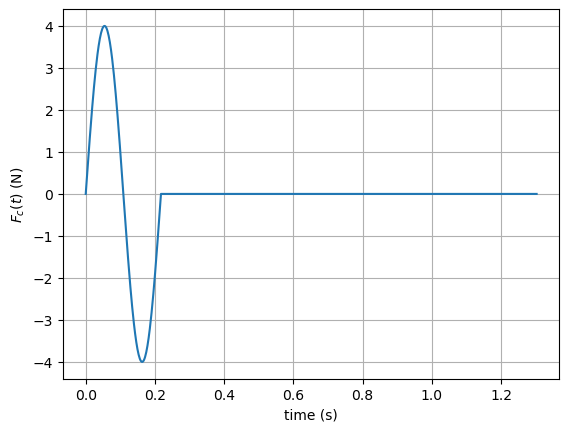

In [5]:
# %matplotlib qt5
# %matplotlib widget
# %matplotlib notebook

figure(1)
plot(tt,ff)
xlabel('time (s)')
ylabel(r'$F_c(t)$ (N)')
grid(True)
show()

The eigenfunctions for the spanwise uniform cantilevered beam are given by Meirovitch equation (o) ( part of example 8.4, on p. 401):

$$ Y_r(x) = A_r \left[ \sin \beta_rx - \sinh \beta_rx - \gamma_r(\cos \beta_rx - \cosh \beta_rx) \right]\;, r = 1,2, \ldots $$

where

$$ \gamma_r = \frac{\sin \beta_rL + \sinh \beta_rL}{\cos \beta_rL + \cosh \beta_rL} \;. $$

We shall choose $A_r = 1$ in our calculations and then normalize the calculated modes such that

$$ m\int_0^L (Y_r(x))^2 \; dx = 1 $$

(see Meirovitch equation (8.106) p. 408).

Since $\beta^4 = \omega^2 m/(EI)$, it follows that

$$ \omega_r = (\beta_r L)^2 \sqrt{\frac{EI}{mL^4}} \;. $$

In [6]:
beta_1L = sqrt(ω_1/bconst)
beta_2L = sqrt(ω_2/bconst)
beta_3L = sqrt(ω_3/bconst)
beta_4L = sqrt(ω_4/bconst)

beta_1 = beta_1L/L
beta_2 = beta_2L/L
beta_3 = beta_3L/L
beta_4 = beta_4L/L

In [7]:
gamma_1 = (sin(beta_1L) + sinh(beta_1L))/(cos(beta_1L) + cosh(beta_1L))
gamma_2 = (sin(beta_2L) + sinh(beta_2L))/(cos(beta_2L) + cosh(beta_2L))
gamma_3 = (sin(beta_3L) + sinh(beta_3L))/(cos(beta_3L) + cosh(beta_3L))
gamma_4 = (sin(beta_4L) + sinh(beta_4L))/(cos(beta_4L) + cosh(beta_4L))

In [8]:
from sympy import symbols, sin, sinh, cos, cosh, integrate, diff, sqrt

x = symbols('x', real=True)

### Calculate eigenfunctions

In [9]:
Y_1 = sin(beta_1*x) - sinh(beta_1*x) - gamma_1*(cos(beta_1*x) - cosh(beta_1*x))
Y_2 = sin(beta_2*x) - sinh(beta_2*x) - gamma_2*(cos(beta_2*x) - cosh(beta_2*x))
Y_3 = sin(beta_3*x) - sinh(beta_3*x) - gamma_3*(cos(beta_3*x) - cosh(beta_3*x))
Y_4 = sin(beta_4*x) - sinh(beta_4*x) - gamma_4*(cos(beta_4*x) - cosh(beta_4*x))

In [10]:
# plot( (Y_1,(x,0,L)), (Y_2,(x,0,L)), (Y_3,(x,0,L)), (Y_4,(x,0,L)) )

### Normalize eigenfunctions

In [11]:
dum1 = mm*integrate(Y_1*Y_1,(x,0,L))
print('dum1 = ',dum1)
Y_1 = Y_1/sqrt(dum1)
print('Changed to {:.15f} after normalization.'
      .format(float(mm*integrate(Y_1*Y_1,(x,0,L)))))

dum1 =  2.73125946839481
Changed to 1.000000000000001 after normalization.


In [12]:
dum1 = mm*integrate(Y_2*Y_2,(x,0,L))
print('dum1 = ',dum1)
Y_2 = Y_2/sqrt(dum1)
print('Changed to {:.15f} after normalization.'
      .format(float(mm*integrate(Y_2*Y_2,(x,0,L)))))

dum1 =  1.41898231536989
Changed to 0.999999999999958 after normalization.


In [13]:
dum1 = mm*integrate(Y_3*Y_3,(x,0,L))
print('dum1 = ',dum1)
Y_3 = Y_3/sqrt(dum1)
print('Changed to {:.15f} after normalization.'
      .format(float(mm*integrate(Y_3*Y_3,(x,0,L)))))

dum1 =  1.47416003009659
Changed to 1.000000000016800 after normalization.


In [14]:
dum1 = mm*integrate(Y_4*Y_4,(x,0,L))
print('dum1 = ',dum1)
Y_4 = Y_4/sqrt(dum1)
print('Changed to {:.15f} after normalization.'
      .format(float(mm*integrate(Y_4*Y_4,(x,0,L)))))

dum1 =  1.47177595200218
Changed to 0.999999970592124 after normalization.


Define modal damping ratios: select value of 0.02 for mode 1 and 0.01 for modes 2 to 4.

In [15]:
ζ_1 = 0.02
ζ_2 = 0.01
ζ_3 = 0.01
ζ_4 = 0.01

In [16]:
Y_1_tip = float(Y_1.subs(x,L))
Y_2_tip = float(Y_2.subs(x,L))
Y_3_tip = float(Y_3.subs(x,L))
Y_4_tip = float(Y_4.subs(x,L))

### Runge-Kutta solution

to determine the four modal displacement dynamic responses $\eta_r(t)$ to the calculated modal excitation forces $N_r(t)$.

To solve the four differential equations

$$ \frac{d^2 \eta_r(t)}{dt^2} + 2\zeta_r \omega_r \frac{d \eta_r(t)}{dt} + \omega_r^2 \eta_r(t) = N_r(t) = F_c(t)Y_r(L) \;, r = 1, 2, \ldots $$

with the Runge-Kutta method, we need to create four state-space representations of the above differential equations:

$$ \left[ \begin{array}{c} \dot{\eta}_r \\[2mm] \ddot{\eta}_r \end{array} \right] =
\left[ \begin{array}{cc} 0 & 1 \\[2mm] -\omega_r^2 & -2\zeta_r \omega_r \end{array} \right] 
\left[ \begin{array}{c} \eta_r \\[2mm] \dot{\eta}_r \end{array} \right] +
\left[ \begin{array}{c} 0 \\[2mm] Y_r(L) \end{array} \right] F_c(t) \; , r = 1, 2, \ldots $$

In [17]:
A_1 = array([[0.0, 1.0],[-ω_1*ω_1, -2*ζ_1*ω_1]])
B_1 = array([0.0, Y_1_tip])
sol1 = solve_ivp(xdot,t_span,array([0.0,0.0]),
                 t_eval=tt,args=(A_1,B_1,Fca,alpha_e))

In [18]:
A_2 = array([[0.0, 1.0],[-ω_2*ω_2, -2*ζ_2*ω_2]])
B_2 = array([0.0, Y_2_tip])
sol2 = solve_ivp(xdot,t_span,array([0.0,0.0]),
                 t_eval=tt,args=(A_2,B_2,Fca,alpha_e))

In [19]:
A_3 = array([[0.0, 1.0],[-ω_3*ω_3, -2*ζ_3*ω_3]])
B_3 = array([0.0, Y_3_tip])
sol3 = solve_ivp(xdot,t_span,array([0.0,0.0]),
                 t_eval=tt,args=(A_3,B_3,Fca,alpha_e))

In [20]:
A_4 = array([[0.0, 1.0],[-ω_4*ω_4, -2*ζ_4*ω_4]])
B_4 = array([0.0, Y_4_tip])
sol4 = solve_ivp(xdot,t_span,array([0.0,0.0]),
                 t_eval=tt,args=(A_4,B_4,Fca,alpha_e))

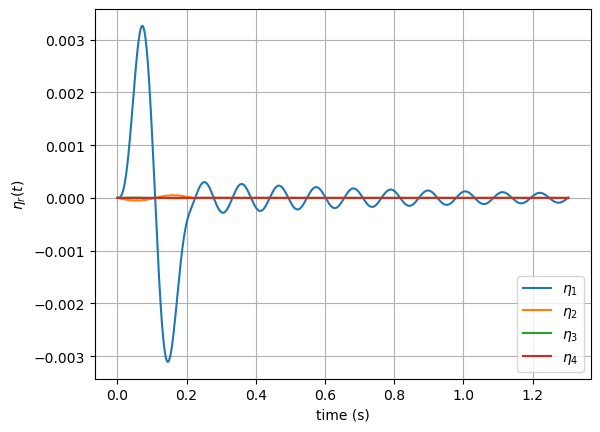

In [21]:
figure(2)
plot(sol1.t,sol1.y[0],label=r'$\eta_1$')
plot(sol2.t,sol2.y[0],label=r'$\eta_2$')
plot(sol3.t,sol3.y[0],label=r'$\eta_3$')
plot(sol4.t,sol4.y[0],label=r'$\eta_4$')
grid(True)
xlabel('time (s)')
ylabel(r'$\eta_r(t)$')
legend(loc='lower right')
show()

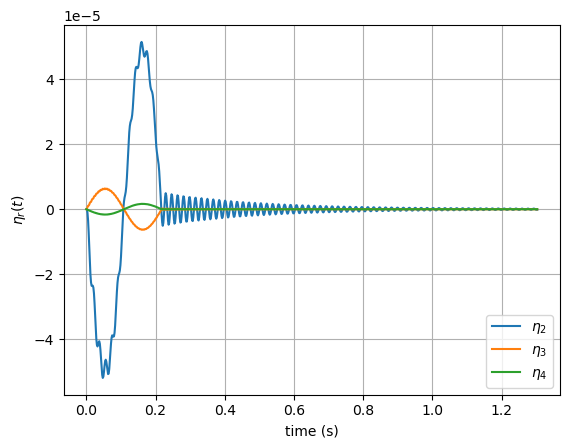

In [22]:
figure(3)
plot(sol2.t,sol2.y[0],label=r'$\eta_2$')
plot(sol3.t,sol3.y[0],label=r'$\eta_3$')
plot(sol4.t,sol4.y[0],label=r'$\eta_4$')
grid(True)
xlabel('time (s)')
ylabel(r'$\eta_r(t)$')
legend(loc='lower right')
show()

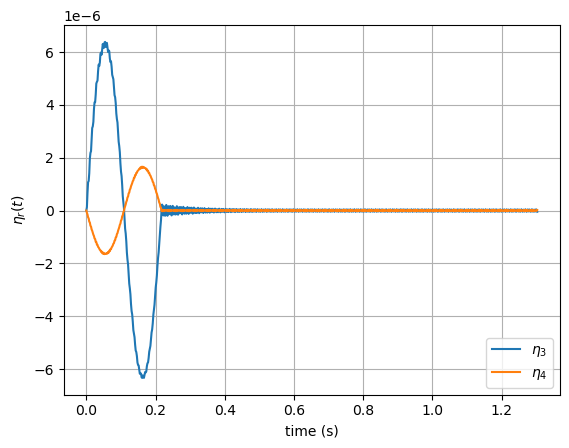

In [23]:
figure(4)
plot(sol3.t,sol3.y[0],label=r'$\eta_3$')
plot(sol4.t,sol4.y[0],label=r'$\eta_4$')
grid(True)
xlabel('time (s)')
ylabel(r'$\eta_r(t)$')
legend(loc='lower right')
show()

### Make sure

that we have a common time base for all four modal solutions.

In [24]:
print('Check sol1.t:',max(abs(tt - sol1.t)))
print('Check sol2.t:',max(abs(tt - sol2.t)))
print('Check sol3.t:',max(abs(tt - sol3.t)))
print('Check sol4.t:',max(abs(tt - sol4.t)))

Check sol1.t: 0.0
Check sol2.t: 0.0
Check sol3.t: 0.0
Check sol4.t: 0.0


### Transform calculated responses

in modal coordinates back to $y(x,t)$; here specifically to $y(L,t)$, that is, the tip deflection of the beam as a fucntion of time.

In [25]:
ytip_1to3 = []   # Tip response calculated by terminating
                 #  the modal summation at the 3rd mode.
ytip_1to4 = []   # Tip response calculated by terminating
                 #  the modal summation at the 4th mode,
                 #  to see what difference the 4th mode makes.
for indx,t in enumerate(tt):
    dum2 = (Y_1_tip*sol1.y[0][indx] + 
            Y_2_tip*sol2.y[0][indx] +
            Y_3_tip*sol3.y[0][indx])
    ytip_1to3.append(dum2)
    ytip_1to4.append(dum2 + 
            Y_4_tip*sol4.y[0][indx])

ytip_1to3 = array(ytip_1to3)
ytip_1to4 = array(ytip_1to4)

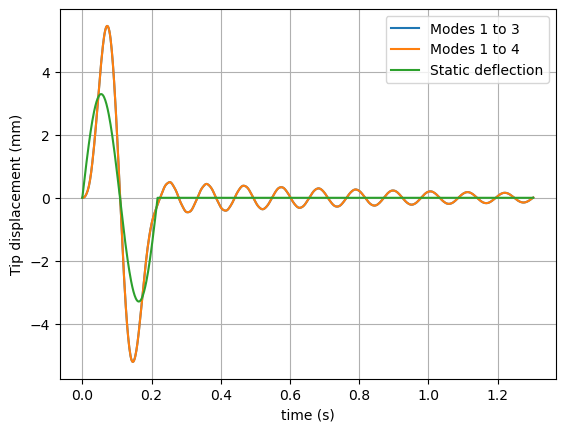

In [26]:
figure(5)
plot(tt,ytip_1to3*1000.0,label = 'Modes 1 to 3')
plot(tt,ytip_1to4*1000.0,label = 'Modes 1 to 4')
plot(tt,ff*L**3/(3*E*I)*1000.0,
     label = 'Static deflection') # Meirovitch table 1.2
                                  #      p. 37, 8th entry.
grid(True)
xlabel('time (s)')
ylabel('Tip displacement (mm)')
legend(loc='upper right')
show()